# ✈ AeroShield — Airline Disruption Intelligence Platform
**Layer 1 — Python Analytics & ML Pipeline**

| | |
|---|---|
| **Author** | Daksh |
| **Stack** | Python · SQL · Power BI |
| **Dataset** | BTS On-Time Performance (flight-level, 28 columns) |
| **Goal** | Predict flight disruption risk + surface operational insights |

---
### Pipeline Sections
1. Import Libraries
2. Load & Combine Monthly CSVs
3. Standardize Column Names
4. Data Cleaning & Missing Value Handling
5. Feature Engineering
6. Summary Table Creation (→ SQL / Power BI)
7. EDA Plots
8. Machine Learning Pipeline
9. Export All Outputs

## ⚙️ Environment Setup
Paths are loaded from a `.env` file — **never hardcode personal paths or passwords**.

Create a `.env` file in your project root (see `.env.example`):
```
DATA_FOLDER=./data
OUTPUT_DIR=./outputs
```

In [ ]:
#pip install python-dotenv

## Section 1 — Import Libraries

In [4]:
# =============================================================================
# SECTION 1 — Import Libraries
# =============================================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

warnings.filterwarnings("ignore")

# ── Load environment variables from .env ─────────────────────────────────────
load_dotenv()  # reads .env file in project root

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "text.color": "#e6edf3", "grid.color": "#21262d",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "monospace", "font.size": 10,
})
PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657","#79c0ff"]
ACCENT  = "#58a6ff"
WARN    = "#f78166"

print("✅ [SECTION 1] Libraries loaded.")

✅ [SECTION 1] Libraries loaded.


## Section 2 — Load & Combine Monthly CSV Files

In [5]:
# =============================================================================
# SECTION 2 — Load & Combine Monthly CSV Files
# =============================================================================
# Paths are loaded from .env — no hardcoded personal paths.
# Default fallback: ./data and ./outputs (relative to project root)

DATA_FOLDER = os.getenv("DATA_FOLDER", "./data")
OUTPUT_DIR  = os.getenv("OUTPUT_DIR",  "./outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data folder : {DATA_FOLDER}")
print(f"Output dir  : {OUTPUT_DIR}")


def load_all_csv(folder: str) -> pd.DataFrame:
    """
    Scans folder for all .csv files, reads and concatenates them.
    Supports any number of monthly BTS On-Time Performance files.
    """
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSV files found in '{folder}'.")
    frames = []
    for f in files:
        print(f"  Loading: {os.path.basename(f)}")
        frames.append(pd.read_csv(f, low_memory=False))
    df = pd.concat(frames, ignore_index=True)
    print(f"\n✅ [SECTION 2] Combined shape: {df.shape}")
    return df


df_raw = load_all_csv(DATA_FOLDER)

Data folder : ./data/raw
Output dir  : ./data/processed
  Loading: Feb2025.csv
  Loading: June2025.csv
  Loading: March2025.csv
  Loading: May2025.csv
  Loading: april2025.csv
  Loading: jan2025.csv

✅ [SECTION 2] Combined shape: (3446676, 28)


## Section 3 — Standardize Column Names

In [6]:
# =============================================================================
# SECTION 3 — Standardize Column Names
# =============================================================================

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace and uppercase all column names."""
    df.columns = df.columns.str.strip().str.upper()
    return df

df_raw = standardize_columns(df_raw)
print(f"✅ [SECTION 3] Columns standardized. Sample: {list(df_raw.columns[:5])}")

✅ [SECTION 3] Columns standardized. Sample: ['YEAR', 'MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER']


## Section 4 — Data Cleaning & Missing Value Handling

In [7]:
# =============================================================================
# SECTION 4 — Data Cleaning & Missing Value Handling
# =============================================================================

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleaning steps:
    1. Coerce numeric columns (errors → NaN)
    2. Fill delay-cause NaNs with 0 (no delay recorded = no cause)
    3. Fill key numeric fields with median (robust to outliers)
    4. Fill binary flags with 0
    5. Drop rows missing ORIGIN / DEST / CARRIER (unusable for analysis)
    """
    df = df.copy()

    numeric_cols = [
        "DEP_DELAY","ARR_DELAY","DEP_DEL15","ARR_DEL15","CANCELLED","DIVERTED",
        "AIR_TIME","DISTANCE","TAXI_OUT","TAXI_IN","CRS_DEP_TIME","CRS_ARR_TIME",
        "CARRIER_DELAY","WEATHER_DELAY","NAS_DELAY","SECURITY_DELAY","LATE_AIRCRAFT_DELAY"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    delay_cause_cols = [
        "CARRIER_DELAY","WEATHER_DELAY","NAS_DELAY","SECURITY_DELAY","LATE_AIRCRAFT_DELAY"
    ]
    for col in delay_cause_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    for col in ["DEP_DELAY","ARR_DELAY","TAXI_OUT","TAXI_IN","AIR_TIME","DISTANCE"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    for col in ["CANCELLED","DIVERTED","DEP_DEL15","ARR_DEL15"]:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    df.dropna(subset=["ORIGIN","DEST","OP_UNIQUE_CARRIER"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"✅ [SECTION 4] Clean shape: {df.shape}")
    return df

df = clean_data(df_raw)

✅ [SECTION 4] Clean shape: (3446676, 28)


## Section 5 — Feature Engineering

In [8]:
# =============================================================================
# SECTION 5 — Feature Engineering
# =============================================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derived columns:
    - disrupted    : binary target (DEP_DELAY>=15 | ARR_DELAY>=15 | CANCELLED | DIVERTED)
    - route        : 'ORIGIN-DEST'
    - is_weekend   : 1 if DAY_OF_WEEK in {6,7}
    - dep_hour     : hour extracted from CRS_DEP_TIME (HHMM → H)
    - arr_hour     : hour extracted from CRS_ARR_TIME
    - time_block   : Night / Morning / Afternoon / Evening bucket
    """
    df = df.copy()

    df["disrupted"] = (
        (df["DEP_DELAY"] >= 15) | (df["ARR_DELAY"] >= 15) |
        (df["CANCELLED"] == 1)  | (df["DIVERTED"]  == 1)
    ).astype(int)

    df["route"]      = df["ORIGIN"].str.strip() + "-" + df["DEST"].str.strip()
    df["is_weekend"] = df["DAY_OF_WEEK"].isin([6, 7]).astype(int)
    df["dep_hour"]   = (df["CRS_DEP_TIME"] // 100).clip(0, 23).astype(int)
    df["arr_hour"]   = (df["CRS_ARR_TIME"] // 100).clip(0, 23).astype(int)

    def time_block(h):
        if   h < 6:  return "Night"
        elif h < 12: return "Morning"
        elif h < 18: return "Afternoon"
        else:         return "Evening"

    df["time_block"] = df["dep_hour"].apply(time_block)

    print(f"✅ [SECTION 5] Features engineered. Disruption rate: {df['disrupted'].mean():.2%}")
    return df

df = engineer_features(df)

✅ [SECTION 5] Features engineered. Disruption rate: 27.12%


## Section 6 — Summary Tables & KPIs

In [9]:
# =============================================================================
# SECTION 6 — Summary Table Creation (Python → exported to SQL / Power BI)
# =============================================================================

def save_fig(name):
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"  📊 Chart saved: {path}")


def minmax_norm(s: pd.Series) -> pd.Series:
    """Min-max normalize; returns 0 series if range is zero (safe div)."""
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng != 0 else pd.Series(np.zeros(len(s)), index=s.index)


# ── 6A. Airport Summary + Airport Fragility Index (AFI) ──────────────────────
airport_summary = (
    df.groupby("ORIGIN")
    .agg(
        total_flights    =("disrupted","count"),
        disrupted_flights=("disrupted","sum"),
        avg_dep_delay    =("DEP_DELAY","mean"),
        avg_arr_delay    =("ARR_DELAY","mean"),
        cancellation_rate=("CANCELLED","mean"),
        diversion_rate   =("DIVERTED","mean"),
    ).reset_index()
)
airport_summary["disruption_rate"] = (
    airport_summary["disrupted_flights"] / airport_summary["total_flights"]
)
airport_summary["norm_disruption"] = minmax_norm(airport_summary["disruption_rate"])
airport_summary["norm_delay"]      = minmax_norm(airport_summary["avg_dep_delay"])
airport_summary["norm_cancel"]     = minmax_norm(airport_summary["cancellation_rate"])
airport_summary["norm_divert"]     = minmax_norm(airport_summary["diversion_rate"])
airport_summary["AFI"] = (
    airport_summary["norm_disruption"] * 0.40 +
    airport_summary["norm_delay"]      * 0.30 +
    airport_summary["norm_cancel"]     * 0.20 +
    airport_summary["norm_divert"]     * 0.10
).round(4)
airport_summary.sort_values("AFI", ascending=False, inplace=True)
print(f"✅ [SECTION 6A] Airport summary: {len(airport_summary)} airports")


# ── 6B. Route Summary + Route Reliability Score (RRS) ────────────────────────
route_summary = (
    df.groupby("route")
    .agg(
        total_flights    =("disrupted","count"),
        disrupted_flights=("disrupted","sum"),
        avg_dep_delay    =("DEP_DELAY","mean"),
        avg_arr_delay    =("ARR_DELAY","mean"),
        avg_distance     =("DISTANCE","mean"),
    ).reset_index()
)
route_summary["disruption_rate"] = (
    route_summary["disrupted_flights"] / route_summary["total_flights"]
)
route_summary["delay_penalty"] = minmax_norm(route_summary["avg_dep_delay"]) * 0.10
route_summary["RRS"] = (
    (1 - route_summary["disruption_rate"] - route_summary["delay_penalty"]) * 100
).clip(0, 100).round(2)
route_summary.sort_values("RRS", ascending=False, inplace=True)
print(f"✅ [SECTION 6B] Route summary: {len(route_summary)} routes")


# ── 6C. Carrier Summary ──────────────────────────────────────────────────────
carrier_summary = (
    df.groupby("OP_UNIQUE_CARRIER")
    .agg(
        total_flights    =("disrupted","count"),
        disrupted_flights=("disrupted","sum"),
        avg_dep_delay    =("DEP_DELAY","mean"),
        avg_arr_delay    =("ARR_DELAY","mean"),
        cancellations    =("CANCELLED","sum"),
        diversions       =("DIVERTED","sum"),
    ).reset_index()
)
carrier_summary["disruption_rate"]   = (
    carrier_summary["disrupted_flights"] / carrier_summary["total_flights"]
)
carrier_summary["cancellation_rate"] = (
    carrier_summary["cancellations"] / carrier_summary["total_flights"]
)
carrier_summary.sort_values("disruption_rate", ascending=False, inplace=True)
print(f"✅ [SECTION 6C] Carrier summary: {len(carrier_summary)} carriers")


# ── 6D. Monthly Summary ───────────────────────────────────────────────────────
monthly_summary = (
    df.groupby(["YEAR","MONTH"])
    .agg(
        total_flights    =("disrupted","count"),
        disrupted_flights=("disrupted","sum"),
        avg_dep_delay    =("DEP_DELAY","mean"),
        cancellations    =("CANCELLED","sum"),
    ).reset_index()
)
monthly_summary["disruption_rate"] = (
    monthly_summary["disrupted_flights"] / monthly_summary["total_flights"]
)
print(f"✅ [SECTION 6D] Monthly summary: {len(monthly_summary)} month-year rows")


# ── 6E. Delay Cause Summary ───────────────────────────────────────────────────
delay_cause_cols = [
    "CARRIER_DELAY","WEATHER_DELAY","NAS_DELAY",
    "SECURITY_DELAY","LATE_AIRCRAFT_DELAY"
]
delay_cause_summary = pd.DataFrame({
    "cause"        : delay_cause_cols,
    "total_minutes": [df[c].sum() for c in delay_cause_cols],
    "avg_minutes"  : [df[c].mean().round(2) for c in delay_cause_cols],
    "flight_count" : [(df[c] > 0).sum() for c in delay_cause_cols],
})
delay_cause_summary["pct_of_total"] = (
    delay_cause_summary["total_minutes"] /
    delay_cause_summary["total_minutes"].sum() * 100
).round(2)
delay_cause_summary.sort_values("total_minutes", ascending=False, inplace=True)
print(f"✅ [SECTION 6E] Delay cause summary complete.")

✅ [SECTION 6A] Airport summary: 346 airports
✅ [SECTION 6B] Route summary: 6630 routes
✅ [SECTION 6C] Carrier summary: 14 carriers
✅ [SECTION 6D] Monthly summary: 6 month-year rows
✅ [SECTION 6E] Delay cause summary complete.


## Section 7 — EDA Plots

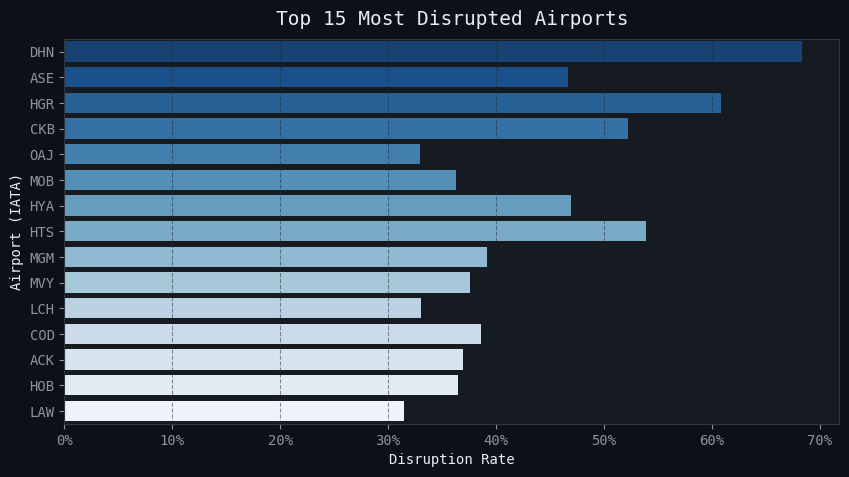

  📊 Chart saved: ./data/processed\plot_top_disrupted_airports.png


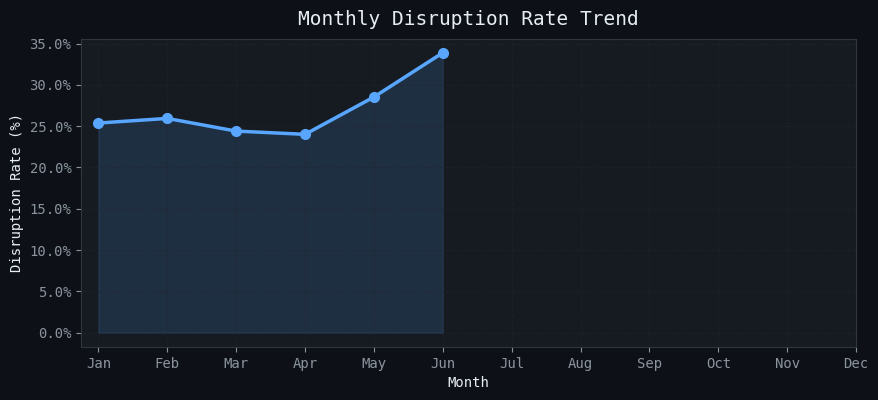

  📊 Chart saved: ./data/processed\plot_monthly_trend.png


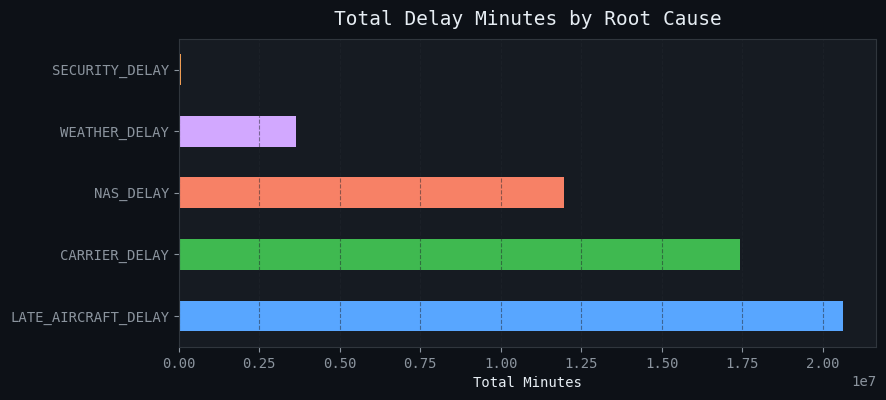

  📊 Chart saved: ./data/processed\plot_delay_causes.png


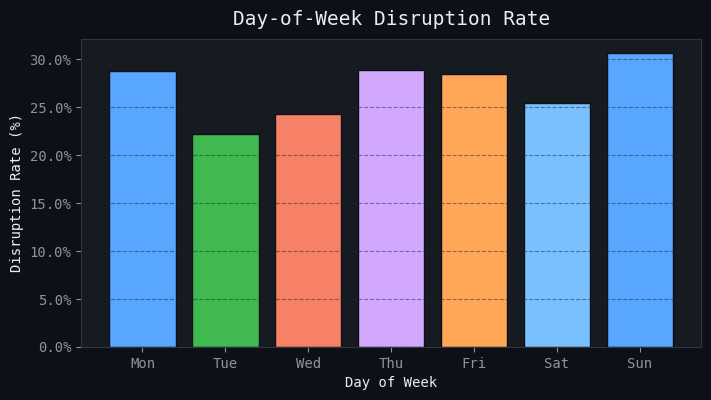

  📊 Chart saved: ./data/processed\plot_dow_trend.png
✅ [SECTION 7] All EDA plots saved.


In [10]:
# =============================================================================
# SECTION 7 — EDA Plots
# =============================================================================

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DAY_LABELS   = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}

# ── Top 15 Disrupted Airports ────────────────────────────────────────────────
top15 = airport_summary.head(15).copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top15, x="disruption_rate", y="ORIGIN", palette="Blues_r", ax=ax)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title("Top 15 Most Disrupted Airports", fontsize=14, pad=10)
ax.set_xlabel("Disruption Rate")
ax.set_ylabel("Airport (IATA)")
ax.grid(axis="x")
save_fig("plot_top_disrupted_airports.png")

# ── Monthly Disruption Trend ──────────────────────────────────────────────────
mt = monthly_summary.groupby("MONTH")["disruption_rate"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mt["MONTH"], mt["disruption_rate"] * 100,
        marker="o", color=ACCENT, linewidth=2.5, markersize=7)
ax.fill_between(mt["MONTH"], mt["disruption_rate"] * 100, alpha=0.15, color=ACCENT)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_title("Monthly Disruption Rate Trend", fontsize=14, pad=10)
ax.set_xlabel("Month")
ax.set_ylabel("Disruption Rate (%)")
ax.grid(True)
save_fig("plot_monthly_trend.png")

# ── Delay Cause Breakdown ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
delay_cause_summary.plot(kind="barh", x="cause", y="total_minutes",
                          color=PALETTE[:5], ax=ax, legend=False)
ax.set_title("Total Delay Minutes by Root Cause", fontsize=14, pad=10)
ax.set_xlabel("Total Minutes")
ax.set_ylabel("")
ax.grid(axis="x")
save_fig("plot_delay_causes.png")

# ── Day-of-Week Trend ─────────────────────────────────────────────────────────
dow = (df.groupby("DAY_OF_WEEK")
       .agg(total=("disrupted","count"), disrupted=("disrupted","sum"))
       .reset_index())
dow["rate"] = dow["disrupted"] / dow["total"]
dow["day"]  = dow["DAY_OF_WEEK"].map(DAY_LABELS)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow["day"], dow["rate"] * 100, color=PALETTE[:7], edgecolor="#0d1117")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_title("Day-of-Week Disruption Rate", fontsize=14, pad=10)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Disruption Rate (%)")
ax.grid(axis="y")
save_fig("plot_dow_trend.png")

print("✅ [SECTION 7] All EDA plots saved.")

## Section 8 — Machine Learning Pipeline
> ⚠️ **Zero data leakage**: only pre-departure features are used. `DEP_DELAY`, `ARR_DELAY`, and all post-flight columns are excluded from model input.


✅ [SECTION 8] Train: 2,757,340  Test: 689,336
   Disruption rate (train): 27.12%

───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

Not Disrupted       0.81      0.58      0.68    502386
    Disrupted       0.36      0.64      0.46    186950

     accuracy                           0.60    689336
    macro avg       0.59      0.61      0.57    689336
 weighted avg       0.69      0.60      0.62    689336

{'accuracy': 0.5991, 'precision': 0.3638, 'recall': 0.6391, 'f1': 0.4637, 'roc_auc': 0.652}

───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

Not Disrupted       0.82      0.50      0.62    502386
    Disrupted       0.34      0.70      0.46    186950

     accuracy                           0.55    689336
    mac

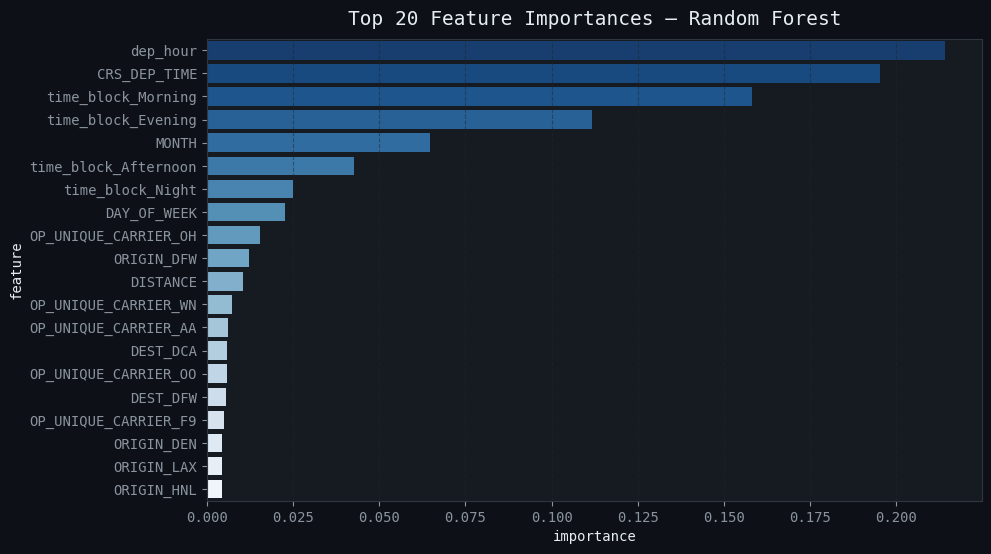

  📊 Chart saved: ./data/processed\plot_rf_feature_importance.png


In [14]:
# =============================================================================
# SECTION 8 — Machine Learning Pipeline
# =============================================================================
# Only pre-departure features — zero leakage from post-flight data.

FEATURES = [
    "MONTH","DAY_OF_WEEK","OP_UNIQUE_CARRIER","ORIGIN","DEST",
    "CRS_DEP_TIME","DISTANCE","dep_hour","is_weekend","time_block",
]
TARGET = "disrupted"

ml_df = df[FEATURES + [TARGET]].dropna()
X = ml_df[FEATURES]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n✅ [SECTION 8] Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"   Disruption rate (train): {y_train.mean():.2%}")

# ── Preprocessing ─────────────────────────────────────────────────────────────
cat_cols = ["OP_UNIQUE_CARRIER","ORIGIN","DEST","time_block"]
num_cols = [c for c in FEATURES if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(with_mean=False), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore",
                          sparse_output=True), cat_cols),
])

# ── Train + Evaluate ─────────────────────────────────────────────────────────
def train_evaluate(name, model, preprocessor, X_train, y_train, X_test, y_test):
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_prob  = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        "model"    : name,
        "accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc"  : round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f"\n{'─'*55}\n  {name}\n{'─'*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Not Disrupted","Disrupted"]))
    print({k: v for k, v in metrics.items() if k != "model"})
    return metrics, pipe


res_lr, pipe_lr = train_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=500, class_weight="balanced", random_state=42),
    preprocessor, X_train, y_train, X_test, y_test
)

res_rf, pipe_rf = train_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=150, max_depth=12,
                            class_weight="balanced", random_state=42, n_jobs=-1),
    preprocessor, X_train, y_train, X_test, y_test
)

comparison_df = pd.DataFrame([res_lr, res_rf]).set_index("model")
print(f"\n✅ [SECTION 8] Model Comparison:\n{comparison_df.to_string()}")

# ── Feature Importance (RF) ───────────────────────────────────────────────────
ohe_cols    = pipe_rf["pre"].named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
all_feat    = num_cols + ohe_cols
feat_imp_df = (
    pd.DataFrame({"feature": all_feat,
                  "importance": pipe_rf["clf"].feature_importances_})
    .sort_values("importance", ascending=False).head(20).reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="Blues_r", ax=ax)
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=14, pad=10)
ax.grid(axis="x")
save_fig("plot_rf_feature_importance.png")

## Section 9 — Export All Outputs

In [16]:
# =============================================================================
# SECTION 9 — Export All Outputs (→ SQL Loader / Power BI)
# =============================================================================

exports = {
    "flights_cleaned.csv"       : df,
    "airport_summary.csv"       : airport_summary,
    "route_summary.csv"         : route_summary,
    "carrier_summary.csv"       : carrier_summary,
    "monthly_summary.csv"       : monthly_summary,
    "delay_cause_summary.csv"   : delay_cause_summary,
    "model_comparison.csv"      : comparison_df.reset_index(),
    "rf_feature_importance.csv" : feat_imp_df,
}

for fname, dataframe in exports.items():
    path = os.path.join(OUTPUT_DIR, fname)
    dataframe.to_csv(path, index=False)
    print(f"  ✅ Saved: {fname}  ({len(dataframe):,} rows)")

print(f"\n🎉 [SECTION 9] All outputs exported to: {OUTPUT_DIR}")
print("    Next step → Run sql_loader.ipynb to push tables into PostgreSQL")

  ✅ Saved: flights_cleaned.csv  (3,446,676 rows)
  ✅ Saved: airport_summary.csv  (346 rows)
  ✅ Saved: route_summary.csv  (6,630 rows)
  ✅ Saved: carrier_summary.csv  (14 rows)
  ✅ Saved: monthly_summary.csv  (6 rows)
  ✅ Saved: delay_cause_summary.csv  (5 rows)
  ✅ Saved: model_comparison.csv  (2 rows)
  ✅ Saved: rf_feature_importance.csv  (20 rows)

🎉 [SECTION 9] All outputs exported to: ./data/processed
    Next step → Run sql_loader.ipynb to push tables into PostgreSQL
